In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("emails.csv")
df.head(10)

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1
5,"Subject: great nnews hello , welcome to medzo...",1
6,Subject: here ' s a hot play in motion homela...,1
7,Subject: save your money buy getting this thin...,1
8,Subject: undeliverable : home based business f...,1
9,Subject: save your money buy getting this thin...,1


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [7]:
df.describe()

,spam
count,5728.000000
mean,0.238827
std,0.426404
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,1.000000


In [9]:
df.shape

(5728, 2)

In [12]:
df.columns

Index(['text', 'spam'], dtype='object')

In [13]:
df.isnull().sum()

text    0
spam    0
dtype: int64

In [15]:
df['spam'].value_counts()
# 0 Not Spam (Ham)
# 1 Spam

spam
0    4360
1    1368
Name: count, dtype: int64

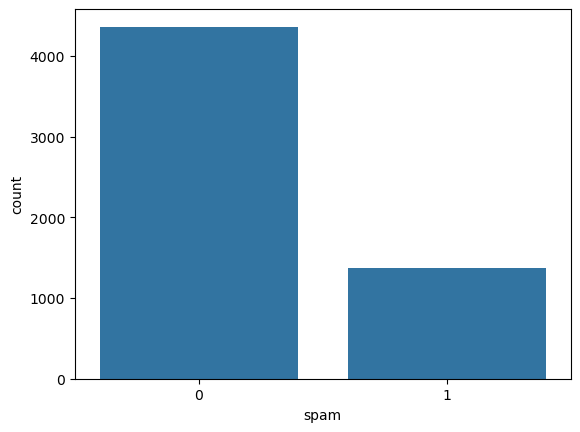

In [17]:
sns.countplot(x='spam', data=df)
plt.show()

In [21]:
import nltk
import string
from nltk.corpus import stopwords


In [22]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [23]:
stop_words = set(stopwords.words('english'))


In [26]:
def clean_text(text):

    text = text.lower()

    text = text.translate(str.maketrans('','',string.punctuation))

    text = text.replace("subject","")

    words = text.split()
    words = [word for word in words if word not in stop_words]

    return " ".join(words)

In [27]:
df['clean_text'] = df['text'].apply(clean_text)

In [28]:
df[['text', 'clean_text']].head()

,text,clean_text
0,Subject: naturally irresistible your corporate...,naturally irresistible corporate identity lt r...
1,Subject: the stock trading gunslinger fanny i...,stock trading gunslinger fanny merrill muzo co...
2,Subject: unbelievable new homes made easy im ...,unbelievable new homes made easy im wanting sh...
3,Subject: 4 color printing special request add...,4 color printing special request additional in...
4,"Subject: do not have money , get software cds ...",money get software cds software compatibility ...


In [57]:
df['text_length'] = df['text'].apply(len)
df['text_length']

0       1484
1        598
2        448
3        500
4        235
        ... 
5723    1189
5724    1167
5725    2131
5726    1060
5727    2331
Name: text_length, Length: 5728, dtype: int64

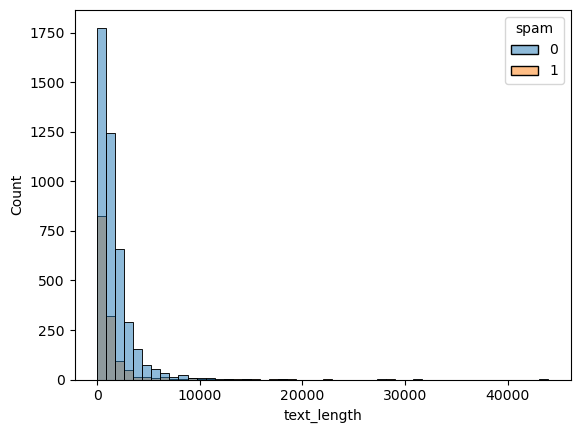

In [30]:
sns.histplot(data=df, x='text_length',hue='spam',bins=50)
plt.show()

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer 

In [32]:
tfidf = TfidfVectorizer()

In [33]:
x = tfidf.fit_transform(df['clean_text'])

In [34]:
y = df['spam']

In [35]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)

In [36]:
x.shape

(5728, 37182)

In [38]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()

model.fit(x_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [41]:
y_pred = model.predict(x_test)
y_pred

array([0, 0, 0, ..., 1, 0, 0], shape=(1146,))

In [42]:
y_test

4445    0
4118    0
3893    0
4210    0
5603    0
       ..
3651    0
1760    0
733     1
4698    0
4339    0
Name: spam, Length: 1146, dtype: int64

In [43]:
model.score(x_test,y_test)

0.8891797556719022

In [45]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[856,   0],
       [127, 163]])

In [47]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      1.00      0.93       856
           1       1.00      0.56      0.72       290

    accuracy                           0.89      1146
   macro avg       0.94      0.78      0.83      1146
weighted avg       0.90      0.89      0.88      1146



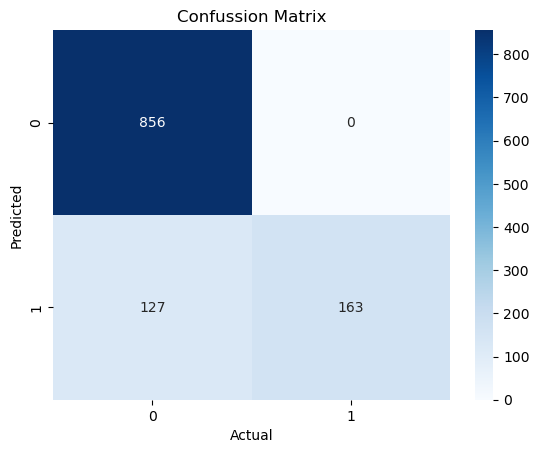

In [56]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Confussion Matrix")
plt.show()

In [55]:
message = ["Congratulations! You have won a free iphone. click here now!"]

message_vector = tfidf.transform(message)

prediction = model.predict(message_vector)

print(prediction)

[0]
